# Lattice model: MCMC analysis


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import matplotlib.ticker as mticker
import os, sys
from Bio import SeqIO
from tqdm import tqdm
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from Bio import SeqIO
from sklearn.cluster import KMeans

main_path = '../'

sys.path.append(main_path + 'PGM/source/')
sys.path.append(main_path + 'PGM/utilities/')
import utilities, Proteins_utils, sequence_logo, plots_utils, RBM_utils

sys.path.append(main_path + 'path/')
#importlib

from path import *

import lattice







e:\ESCAPE_PATHS\lattice\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\lattice\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


# Lattice proteins

In [2]:
RBM=RBM_utils.loadRBM('rbm/RBM_structure_0_beta_100')



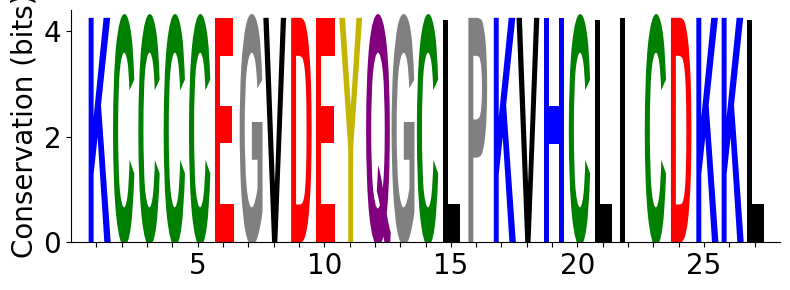

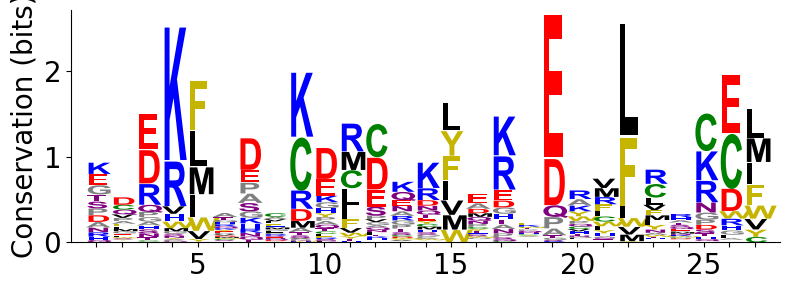

In [3]:
msa_seqs=Proteins_utils.load_FASTA('msa/output_msa_structure_0_beta_100.fasta')
PROTEIN_INIT=Proteins_utils.load_FASTA('msa/output_msa_structure_0_beta_1000.fasta')[0] # Load the protein sequence from the FASTA file.
position_weight_init = utilities.average(np.array([PROTEIN_INIT]),c=20) # Compute Position Weight Matrix (i.e. frequency of each amino acid at each site)
position_weight_msa = utilities.average(msa_seqs,c=20) # Compute Position Weight Matrix (i.e. frequency of each amino acid at each site)

sequence_logo.Sequence_logo(position_weight_init, nrows=1, x_start=0,ticks_every=5,ticks_labels_size=20); # Visualize sequence logo of the MSA.
sequence_logo.Sequence_logo(position_weight_msa, nrows=1, x_start=0,ticks_every=5,ticks_labels_size=20); # Visualize sequence logo of the MSA.


In [4]:
def one_hot_encode_concat(s):
    # Number of categories for one-hot encoding, 21 for values 0 through 20
    num_categories = 20
    # Create a numpy array of zeros with shape [len(s), num_categories]
    one_hot_matrix = np.zeros((len(s), num_categories))

    # Use numpy indexing to set the appropriate elements to 1
    one_hot_matrix[np.arange(len(s)), s.astype(int)] = 1

    # Flatten the one-hot matrix to a 1D array
    one_hot_encoded = one_hot_matrix.flatten()

    return one_hot_encoded
one_hot_seq=one_hot_encode_concat(PROTEIN_INIT)


In [5]:
POS_CHARGE = {"K", "R", "H"}
NEG_CHARGE = {"D", "E"}

sites = np.array([9, 10, 11, 12, 13, 16, 17, 25, 26]) - 1
w = np.zeros((PROTEIN_INIT.shape[0] * 20))

for site in sites:
    wt_idx = PROTEIN_INIT[site]  # Integer index of WT amino acid
    wt_char = CODE_RBM[wt_idx]  # Character (e.g., 'K')

    for i in range(20):
        mut_char = CODE_RBM[i]  # Character of the mutation

        # Determine charge status
        wt_is_pos = wt_char in POS_CHARGE
        wt_is_neg = wt_char in NEG_CHARGE
        mut_is_pos = mut_char in POS_CHARGE
        mut_is_neg = mut_char in NEG_CHARGE

        # Logic: WT is (+) and Mut is (-) OR WT is (-) and Mut is (+)
        is_charge_flip = (wt_is_pos and mut_is_neg) or (wt_is_neg and mut_is_pos)

        # Check if mutation exists and if it is a charge flip
        if i != wt_idx and is_charge_flip:
            print(site)
            w[site * 20 + i] = 1

8
8
8
9
9
9
16
16
24
24
25
25


In [7]:
g = np.expand_dims(RBM.vlayer.fields[:, :], axis=-1).reshape(-1)
g

array([ 5.5973649e+00, -8.5287981e+00,  5.6947970e+00,  6.3536167e+00,
       -8.5287981e+00,  6.2416735e+00,  4.9705377e+00, -8.5287981e+00,
        6.4545827e+00, -8.5287981e+00, -8.5287981e+00,  5.4518480e+00,
        5.8866639e+00,  4.6317196e+00,  5.3492398e+00,  5.8674722e+00,
        5.7308707e+00, -8.5287981e+00, -8.5287981e+00, -8.5287981e+00,
        1.3064190e+00,  1.7228533e+00,  2.0821664e+00,  7.9428303e-01,
        1.1220558e+00,  9.0630198e-01, -1.2067281e-01,  9.4564426e-01,
       -1.2872100e+01,  5.1966912e-01,  8.9631569e-01, -1.2015297e+00,
        1.0168468e+00,  1.8703017e+00, -5.4892939e-01,  4.2153913e-01,
       -5.0140923e-01,  1.3704692e+00,  1.6714419e-01,  1.0263195e-01,
        4.4548912e+00,  3.4386308e+00,  6.7715664e+00,  6.7155509e+00,
       -8.8535280e+00,  4.7394638e+00,  4.5156798e+00, -8.8535280e+00,
       -8.8535280e+00, -8.8535280e+00, -8.8535280e+00,  4.1092129e+00,
        4.5217371e+00,  5.0936346e+00,  6.0098906e+00,  4.6205592e+00,
      

In [8]:
def hamming(v, vbis):
    """
    return the hamming distance between v and vbis
    """
    return sum([1 for (start, end) in zip(v, vbis) if start != end])




# Biaised paths sparse W: transform L in F

In [9]:



np.dot(one_hot_encode_concat(PROTEIN_INIT),w)



0.0

# Analysis of created paths

In [12]:

k=3 #nb clusters
# ───────────────────────────  HYDROPHOBICITY COLOURS  ───────────────────── #
def aa_color(letter):
    if letter in ['C']:
        return 'limegreen'                     # sulfur
    elif letter in ['F', 'W', 'Y']:
        return (0.78, 0.71, 0.00)             # aromatics – gold
    elif letter in ['Q', 'N', 'S', 'T']:
        return 'mediumorchid'                 # polar uncharged
    elif letter in ['V', 'L', 'I', 'M']:
        return 'dimgray'                      # aliphatic hydrophobics
    elif letter in ['K', 'R', 'H']:
        return 'royalblue'                    # positively charged
    elif letter in ['D', 'E']:
        return 'crimson'                      # negatively charged
    elif letter in ['A', 'P', 'G']:
        return 'lightgrey'                    # small / special
    else:
        return 'black'

# ───────────────────────────  LATTICE GEOMETRY  ─────────────────────────── #
CODE_RBM = [
    "A", "C", "D", "E", "F", "G", "H", "I", "K", "L",
    "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y",
]
LATTICE = {
    25: (0,  0), 26: (1,  0),  9: (2,  0),
    12: (0, -1), 11: (1, -1), 10: (2, -1),
    13: (0, -2), 16: (1, -2), 17: (2, -2),
}
BONDS = [
    (25, 26),          # top row
    (12, 11), (11, 10),
    (16, 17),
    (12, 13),          # left column
    (9, 10),           # vertical 9 ↔ 10
]
EPITOPE_SITES = list(LATTICE.keys())
sites_idx      = np.array(EPITOPE_SITES) - 1

# ───────────────────────────  CONSENSUS & CARTOON  ──────────────────────── #
def consensus_epitope(seq_block: np.ndarray) -> dict[int, str]:
    mapping = {}
    epi_sub = seq_block[:, sites_idx]                     # (n_seq, 9)
    for site, col in zip(EPITOPE_SITES, epi_sub.T):
        aa_idx, _ = Counter(col).most_common(1)[0]
        mapping[site] = CODE_RBM[aa_idx]
    return mapping                                        # {site: 'A', …}

def draw_epitope(ax, centre, residue_map, edge_colour,
                 scale=0.35, radius=0.14, z=3):
    """Draw 3×3 lattice cartoon centred on (cx, cy)."""
    cx, cy = centre
    # bonds
    for a, b in BONDS:
        xa, ya = LATTICE[a]
        xb, yb = LATTICE[b]
        ax.plot([cx + scale*xa, cx + scale*xb],
                [cy + scale*ya, cy + scale*yb],
                lw=1.4, color=edge_colour, zorder=z)
    # circles + letters
    for site, (dx, dy) in LATTICE.items():
        res = residue_map[site]
        circ = Circle((cx + scale*dx, cy + scale*dy),
                      radius*scale,
                      facecolor=aa_color(res),
                      edgecolor=edge_colour,
                      lw=1.2, zorder=z+1)
        ax.add_patch(circ)
        ax.text(cx + scale*dx, cy + scale*dy, res,
                ha="center", va="center",
                fontsize=14, color="black", weight='bold',
                zorder=z+2)





reading FASTA: 100%|██████████| 100/100 [00:00<00:00, 1514.94it/s]


Selected path indices for top 3 most frequent escape endpoints: [57, 0, 1]


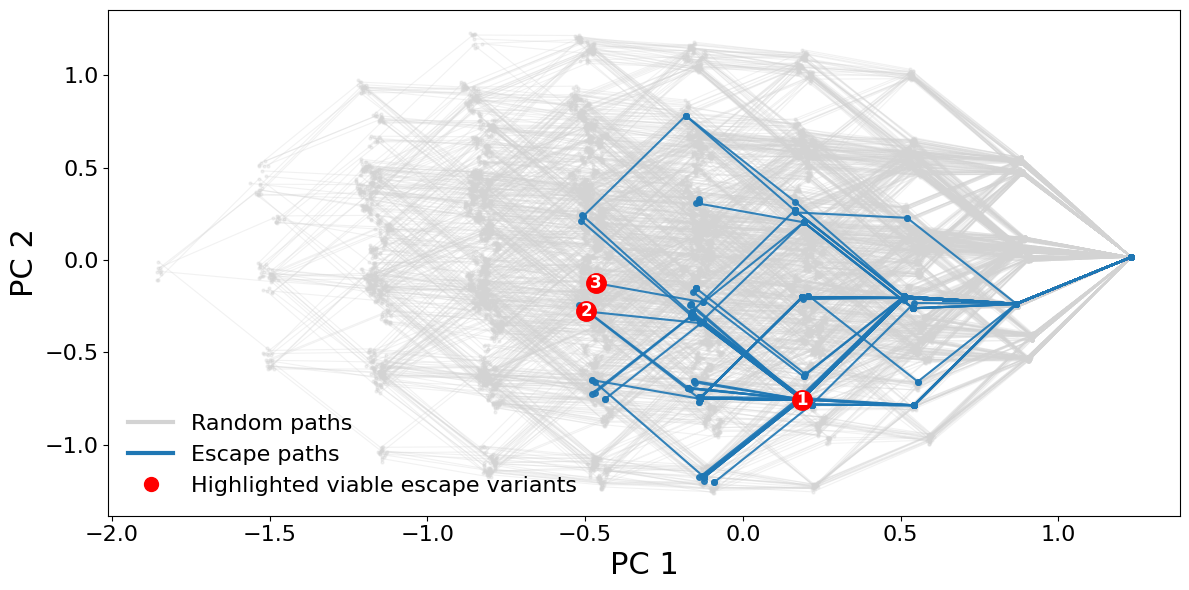

In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Visualise observed “escape” mutation paths against ×10 more neutral random paths.

Changes vs. original script
---------------------------
1. **No clustering** – K-means and colour palette removed.
2. **Highlight three random escape endpoints** – large red dots numbered 1-3.
3. **Second figure** – epitope cartoons for those three selected endpoints only.
---------------------------------------------------------------------------
You still need:
    • CODE_RBM, EPITOPE_SITES, sites_idx,
    • one_hot_encode_concat(), Proteins_utils.seq2num(),
    • consensus_epitope(), draw_epitope().
"""

# ─────────────────────────────── IMPORTS ────────────────────────────────

# ───────────────────────────── PARAMETERS ───────────────────────────────
k          = 3                 # **unused now** (kept for reference)
beta_w     = 10
paths_nb   = 100               # observed escape paths
rand_nb    = paths_nb * 10     # 10 × more random paths
steps      = 11                 # WT + 6 mutations
dir_in     = f"paths/w_upper_T10_beta_ab_{beta_w}/"
rng        = np.random.default_rng(0)

# ───────────────────── LOAD OBSERVED (ESCAPE) PATHS ─────────────────────
obs_seqs = []
for p in tqdm(range(paths_nb), desc="reading FASTA"):
    fasta = os.path.join(dir_in, f"output_{p}.fasta")
    obs_seqs.extend(SeqIO.parse(fasta, "fasta"))        # 7 seq per path

obs_num  = Proteins_utils.seq2num(obs_seqs)             # (paths_nb*7, L)
L        = obs_num.shape[1]
wt_num   = obs_num[0].copy()                            # assume first record is WT
obs_path_num = obs_num.reshape(paths_nb, steps, L)

# ─────────────────── BUILD RANDOM MUTATION PATHS ────────────────────────
rand_path_num = np.repeat(wt_num[None, None, :], rand_nb, axis=0)  # (R,1,L)
rand_path_num = np.tile(rand_path_num, (1, steps, 1))              # (R,7,L)

for r in range(rand_nb):
    seq = wt_num.copy()
    for t in range(1, steps):
        pos = rng.choice(sites_idx)           # random epitope position
        aa  = rng.integers(20)
        while aa == seq[pos]:
            aa = rng.integers(20)
        seq[pos] = aa
        rand_path_num[r, t] = seq.copy()

# ─────────────────────── ONE-HOT ENCODING ───────────────────────────────
obs_1hot  = np.array([one_hot_encode_concat(v) for v in obs_path_num.reshape(-1, L)])
rand_1hot = np.array([one_hot_encode_concat(v) for v in rand_path_num.reshape(-1, L)])

# ──────────────────────── PCA (covariance) ──────────────────────────────
def pca_fit_cov(X, n_comp=2):
    """PCA via eigendecomposition of the covariance matrix."""
    mu   = X.mean(axis=0, keepdims=True)
    Xc   = X - mu
    var  = Xc.var(axis=0)
    keep = var > 0                               # drop constant columns
    C    = (Xc[:, keep].T @ Xc[:, keep]) / (Xc.shape[0] - 1)
    _, vecs = np.linalg.eigh(C)                  # ascending eigen-values
    W_use = vecs[:, -n_comp:]                    # top PCs
    W     = np.zeros((X.shape[1], n_comp))
    W[keep] = W_use
    proj = Xc @ W
    return proj, W, mu.ravel()

# coords_rand_flat, eigvecs, mean_rand = pca_fit_cov(rand_1hot, n_comp=2)
# coords_obs_flat = (obs_1hot - mean_rand) @ eigvecs
def pca_fit_direct(X, n_comp=2):
    """
    PCA via SVD directly on centered one-hot matrix.
    Returns:
        coords  - projected coordinates (N, n_comp)
        W       - loadings (n_features, n_comp)
        mu      - mean vector (n_features,)
    """
    mu = X.mean(axis=0, keepdims=True)
    Xc = X - mu
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    coords = U[:, :n_comp] * S[:n_comp]  # projection of samples
    W = Vt[:n_comp].T                    # loadings
    return coords, W, mu.ravel()

# Fit PCA on random paths' one-hot features
coords_rand_flat, eigvecs, mean_rand = pca_fit_direct(rand_1hot, n_comp=2)

# Project observed paths into same space
coords_obs_flat = (obs_1hot - mean_rand) @ eigvecs


coords_rand_path = coords_rand_flat.reshape(rand_nb,  steps, 2)
coords_obs_path  = coords_obs_flat.reshape(paths_nb, steps, 2)

# ───────────────────── PICK THREE RANDOM ESCAPE PATHS ───────────────────
# sel_idx = rng.choice(paths_nb, size=3, replace=False)   # e.g. [17, 42, 8]

# Get final sequences (step 6) from observed paths
final_obs_seqs = obs_path_num[:, -1, :]  # shape (paths_nb, L)

# Convert each sequence to a tuple so it can be hashed
final_seqs_tuples = [tuple(seq) for seq in final_obs_seqs]

# Count frequencies
counts = Counter(final_seqs_tuples)

# Get the 3 most common sequences
top3_seqs = [np.array(seq) for seq, _ in counts.most_common(3)]

# Find an index in obs_path_num matching each top3 sequence
sel_idx = []
for top_seq in top3_seqs:
    for i, seq in enumerate(final_obs_seqs):
        if np.array_equal(seq, top_seq):
            sel_idx.append(i)
            break

print("Selected path indices for top 3 most frequent escape endpoints:", sel_idx)


# ─────────────────────────── PLOT 1: PATHS ──────────────────────────────
plt.rcParams.update({
    'axes.titlesize': 26, 'axes.labelsize': 22,
    'xtick.labelsize': 16, 'ytick.labelsize': 16,
    'legend.fontsize': 16
})
fig, ax = plt.subplots(figsize=(12, 6))

# random paths in grey
for r in range(rand_nb):
    ax.plot(coords_rand_path[r, :, 0], coords_rand_path[r, :, 1],
            color='lightgrey', alpha=0.3, lw=0.8, marker='o', ms=2)

# escape paths in blue
for p in range(paths_nb):
    ax.plot(coords_obs_path[p, :, 0], coords_obs_path[p, :, 1],
            color='tab:blue', alpha=0.9, lw=1.5, marker='o', ms=4)

# highlight selected endpoints
for j, p in enumerate(sel_idx, start=1):
    x, y = coords_obs_path[p, -1]
    ax.plot(x, y, marker='o', ms=14, color='red', zorder=5)
    ax.text(x, y, f'{j}', va='center', ha='center',
            color='white', weight='bold', fontsize=12, zorder=6)

ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
# ax.set_title("Escape (blue) vs. random (grey) mutation paths")
ax.grid(False)

handles = [
    Line2D([0], [0], color='lightgrey', lw=3, label='Random paths'),
    Line2D([0], [0], color='tab:blue', lw=3, label='Escape paths'),
    Line2D([0], [0], marker='o', color='red', lw=0,
           markersize=10, label='Highlighted viable escape variants')
]
ax.legend(handles=handles, frameon=False, loc='best')

plt.tight_layout()
plt.show()


Mean distance to own consensus at step 1 — random: 1.0


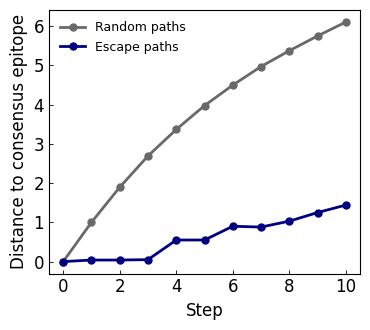

In [ ]:

epitope_idx = np.asarray(sites_idx, dtype=int)

def consensus_on_idx(seqs_at_step, idx, wt=None):
    """Consensus on idx: most frequent residue per site; break ties by preferring WT if given."""
    arr = np.asarray(seqs_at_step)
    L = arr.shape[1]
    cons = np.array(arr[0], copy=True)
    for j in idx:
        counts = Counter(arr[:, j].tolist())
        maxc = max(counts.values())
        candidates = [aa for aa, c in counts.items() if c == maxc]
        if wt is not None and wt[j] in candidates:
            cons[j] = wt[j]
        else:
            # deterministic pick among ties
            cons[j] = candidates[0]
    return cons

def consensus_per_step(paths_num, idx, wt=None):
    """List of per-step consensus sequences for one cohort."""
    N, T, L = paths_num.shape
    return [consensus_on_idx([paths_num[p, t] for p in range(N)], idx, wt=wt) for t in range(T)]

def distances_to_reference_consensus(paths_num, ref_cons_list, idx):
    """Per-path distances to given per-step consensus (Hamming on idx)."""
    N, T, L = paths_num.shape
    Y = np.zeros((N, T), dtype=float)
    for t in range(T):
        cons = ref_cons_list[t]
        # vectorized per-step Hamming on idx
        X = paths_num[:, t][:, idx]                # (N, |E|)
        c = np.tile(np.asarray(cons)[idx], (N, 1)) # (N, |E|)
        Y[:, t] = np.sum(X != c, axis=1)
    return Y

# --- Build each cohort’s OWN consensus (this is what you want) ---
ref_cons_rand = consensus_per_step(rand_path_num, epitope_idx, wt=wt_num)
ref_cons_obs  = consensus_per_step(obs_path_num,  epitope_idx, wt=wt_num)

# Distances to own consensus
Y_rand = distances_to_reference_consensus(rand_path_num, ref_cons_rand, epitope_idx)  # (N_rand, T)
Y_obs  = distances_to_reference_consensus(obs_path_num,  ref_cons_obs,  epitope_idx)  # (N_obs,  T)

# --- Quick sanity check: mean distance at step 1 should be ~1 for random paths with 1 mutation/seq ---
print("Mean distance to own consensus at step 1 — random:",
      Y_rand[:, 1].mean())

# --- Plot mean distance vs step ---
steps = np.arange(Y_obs.shape[1])
m_obs,  s_obs  = Y_obs.mean(0),  Y_obs.std(0, ddof=1)
m_rand, s_rand = Y_rand.mean(0), Y_rand.std(0, ddof=1)

fig, ax = plt.subplots(figsize=(3.8, 3.4))
ax.plot(steps, m_rand, '-o', color='dimgray', lw=2, ms=5, label='Random paths')
ax.plot(steps, m_obs,  '-o', color='navy',    lw=2, ms=5, label='Escape paths')

ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Distance to consensus epitope", fontsize=12)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
#tick fontsize smaller
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)

for s in ax.spines.values():
    s.set_visible(True); s.set_color('black'); s.set_linewidth(0.8)
ax.tick_params(direction='in', length=3, width=0.6)
ax.legend(frameon=False, loc='best', fontsize=9)
plt.tight_layout(); plt.show()


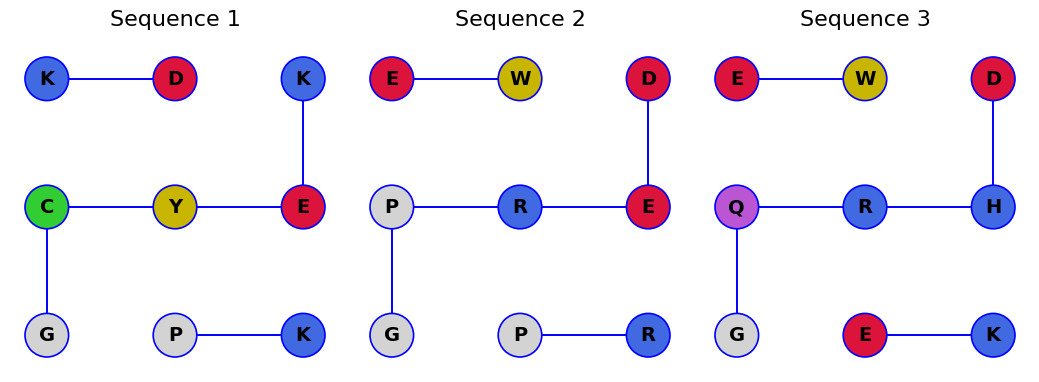

In [15]:

# ──────────────── PLOT 2: EPITOPE CARTOONS (3 ENDPOINTS) ───────────────
n_cols = len(sel_idx)                         # = 3
fig2, axes2 = plt.subplots(1, n_cols,
                           figsize=(3.5 * n_cols, 4),
                           squeeze=False)

for j, (ax_sub, p) in enumerate(zip(axes2[0], sel_idx), start=1):
    ax_sub.set_aspect("equal")
    ax_sub.axis("off")

    # numeric sequence of the final point
    last_seq_num = np.array([obs_path_num[p, -1, :]])     # shape (L,)
    res_map      = consensus_epitope(last_seq_num)  # user-defined

    draw_epitope(ax_sub,
                 centre=(0, 0),
                 residue_map=res_map,
                 edge_colour='blue',
                 scale=0.5, radius=0.17)

    ax_sub.set_title(f"Sequence {j}", fontsize=16, pad=12)

fig2.tight_layout()
plt.show()


# Look at seqs

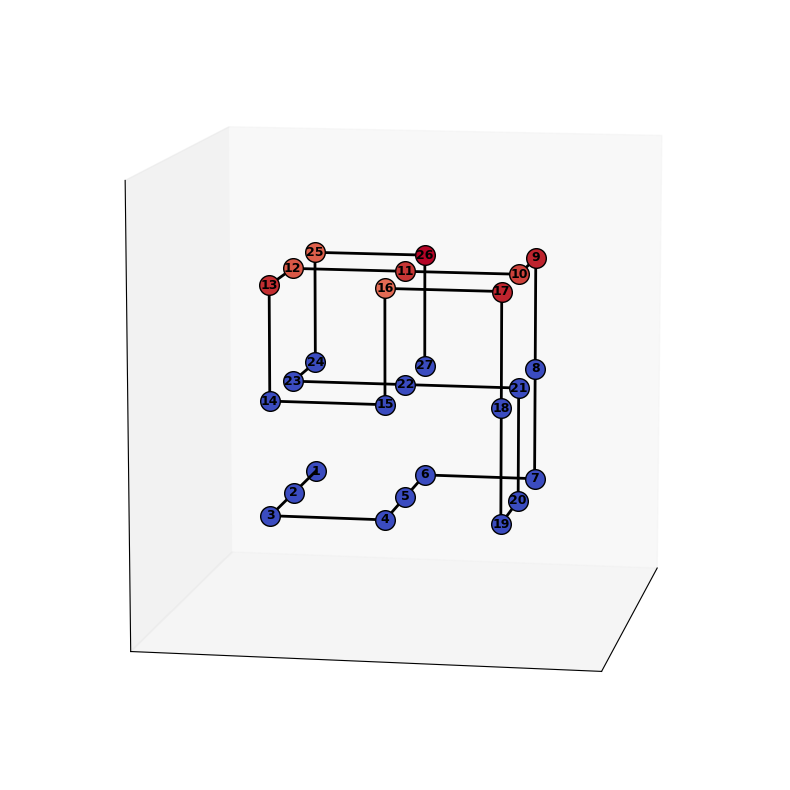

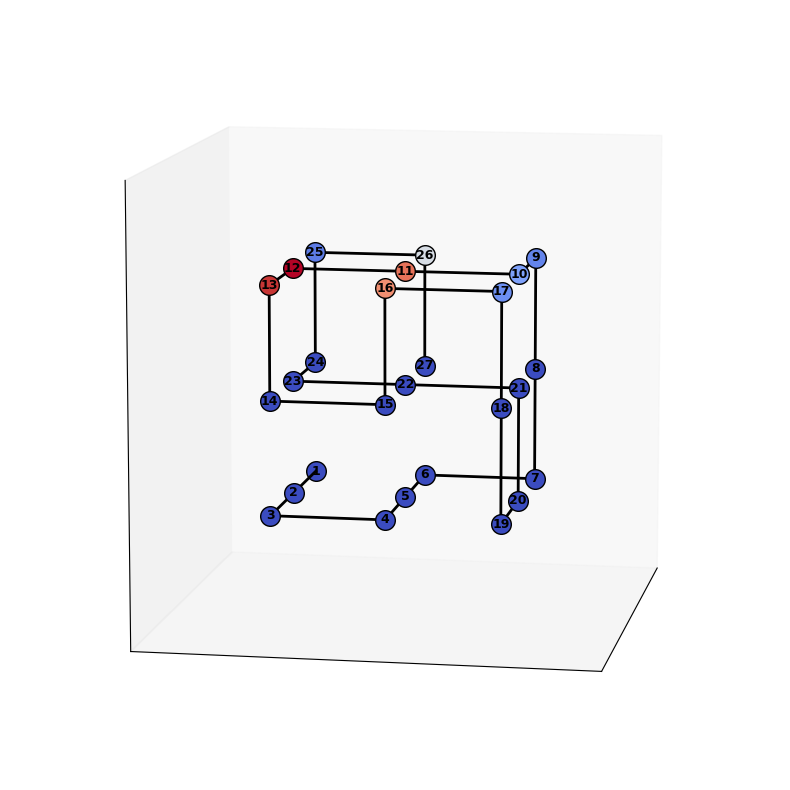

In [16]:
def per_site_pc1_weights(pc1, L, use_abs=True, sites_idx=None, normalize=True):
    """
    eigvecs: (20*L, n_comp) loadings from your PCA (columns = PCs)
    L:       protein length
    use_abs: sum |weights| per site (recommended); if False, uses signed sum
    sites_idx: iterable of epitope indices to keep; others set to 0 (optional)
    normalize: min-max to [0,1] for nicer colouring (optional)
    """
    site_x_aa = pc1.reshape(L, 20)            # (L, 20): site × amino-acid
    if use_abs:
        site_vals = np.abs(site_x_aa).sum(axis=1)
    else:
        site_vals = site_x_aa.sum(axis=1)

    if sites_idx is not None:
        mask = np.zeros(L)
        mask[np.asarray(sites_idx, dtype=int)] = 1.0
        site_vals = site_vals * mask

    if normalize:
        rng = site_vals.max() - site_vals.min()
        if rng > 0:
            site_vals = (site_vals - site_vals.min()) / rng

    return site_vals  # shape (L,)

# --- compute and plot ---
site_weights = per_site_pc1_weights(eigvecs[:, 0] , L, use_abs=True, sites_idx=None, normalize=True)
lattice.plot_lattice_protein(0, node_values=site_weights)
site_weights = per_site_pc1_weights(eigvecs[:, 1] , L, use_abs=True, sites_idx=None, normalize=True)
lattice.plot_lattice_protein(0, node_values=site_weights)



## WT

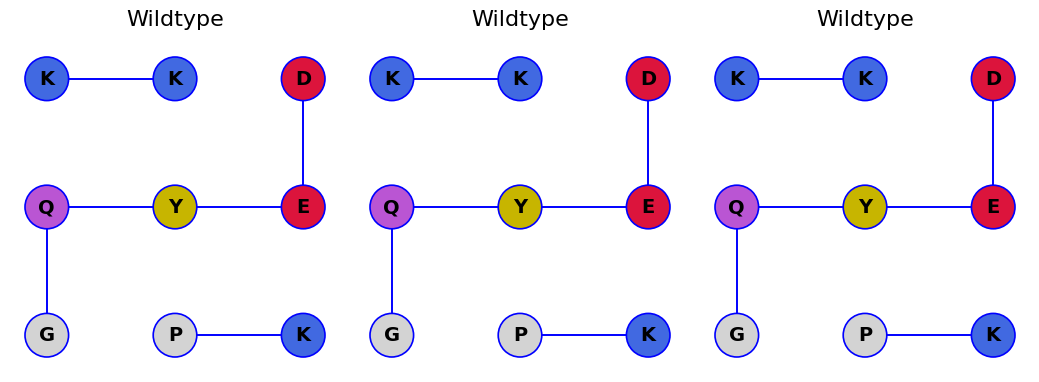

In [17]:
n_cols = len(sel_idx)                         # = 3
fig2, axes2 = plt.subplots(1, n_cols,
                           figsize=(3.5 * n_cols, 4),
                           squeeze=False)

for j, (ax_sub, p) in enumerate(zip(axes2[0], sel_idx), start=1):
    ax_sub.set_aspect("equal")
    ax_sub.axis("off")

    # numeric sequence of the final point
    last_seq_num = np.array([obs_path_num[p, 0, :]])     # shape (L,)
    res_map      = consensus_epitope(last_seq_num)  # user-defined

    draw_epitope(ax_sub,
                 centre=(0, 0),
                 residue_map=res_map,
                 edge_colour='blue',
                 scale=0.5, radius=0.17)

    ax_sub.set_title("Wildtype", fontsize=16, pad=12)

fig2.tight_layout()
plt.show()

# MSA fit

In [18]:

# --- Load MSA and build one-hot as you already do ---
msa_seqs = Proteins_utils.load_FASTA('msa/output_msa_structure_0_beta_1000.fasta')
one_hot_msa = np.array([one_hot_encode_concat(v) for v in msa_seqs])

# Optional: set WT (defaults to first MSA sequence)
wt_seq = msa_seqs[0]



# Pnat

In [19]:
protein_lattice = lattice.ProteinLattice(structure_idx=0)
lattice_model = lattice.LatticeModel(protein_lattice)

    
class customed_lattice:
    def __init__(self, Lattice_model, beta_lattice=1000):
        self.Lattice_model = Lattice_model
      
        self.beta_lattice = beta_lattice

    def __call__(self, v_string):
        v=Proteins_utils.seq2num(v_string)[0]

        v_transfo = lattice.string2seq(v_string)
        score = np.log(self.Lattice_model(v_transfo)) * self.beta_lattice
        return score


In [20]:

# -------------------
# Config
# -------------------
paths_nb = 100
beta_lattice = 1000
beta_w = 10  # only this one
dir_in = f"paths/w_upper_T10_beta_ab_{beta_w}/"

# Plot style (similar to consensus epitope plots)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'font.size': 12,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 300
})

# -------------------
# Collect paths
# -------------------
all_ll_customed_rbm = []  # will hold arrays per path: Pnat (as in your exp(...) transform)
all_ll_biased_rbm   = []  # epitope Hamming distance per path

for path_no in tqdm(range(paths_nb), desc=f"Reading β_w={beta_w}"):
    fasta_file = os.path.join(dir_in, f"output_{path_no}.fasta")
    if not os.path.exists(fasta_file):
        continue

    seqs = list(SeqIO.parse(fasta_file, "fasta"))
    if len(seqs) == 0:
        continue

    wt_seq = str(seqs[0].seq)
    ll_customed = []
    ll_biased   = []

    for record in seqs:
        seq = str(record.seq)
        # Epitope Hamming distance to WT
        # epitope_overlap = sum(seq[j] != wt_seq[j] for j in epitope_sites)
        seq_num=Proteins_utils.seq2num(seq)[0]
        seq_num_one_hot=one_hot_encode_concat(seq_num)
        epitope_overlap=np.dot(seq_num_one_hot, w)
        # Pnat (ground truth) via your custom model
        try:
            pnat = customed_lattice(Lattice_model=lattice_model, beta_lattice=beta_lattice)(seq)
        except Exception:
            continue

        # Your original transform:
        #   ll_c = (pnat - epitope_overlap * beta_w) / beta_lattice
        #   Pnat-like value = exp(ll_c)
        ll_c = pnat / beta_lattice
        ll_customed.append(np.exp(ll_c))

        # Store epitope Hamming
        ll_biased.append(epitope_overlap)

    if len(ll_customed) == 0 or len(ll_biased) == 0:
        continue

    all_ll_customed_rbm.append(np.array(ll_customed))
    all_ll_biased_rbm.append(np.array(ll_biased))

# Early exit if nothing loaded
if len(all_ll_customed_rbm) == 0 or len(all_ll_biased_rbm) == 0:
    raise RuntimeError("No valid paths were loaded for β_w=3. Check input files.")

# Align by common minimum length across paths (if variable length)
min_T = min(arr.shape[0] for arr in all_ll_customed_rbm)
all_ll_customed = [arr[:min_T] for arr in all_ll_customed_rbm]
all_ll_biased   = [arr[:min_T] for arr in all_ll_biased_rbm]
steps = np.arange(min_T)



Reading β_w=10: 100%|██████████| 100/100 [02:30<00:00,  1.50s/it]


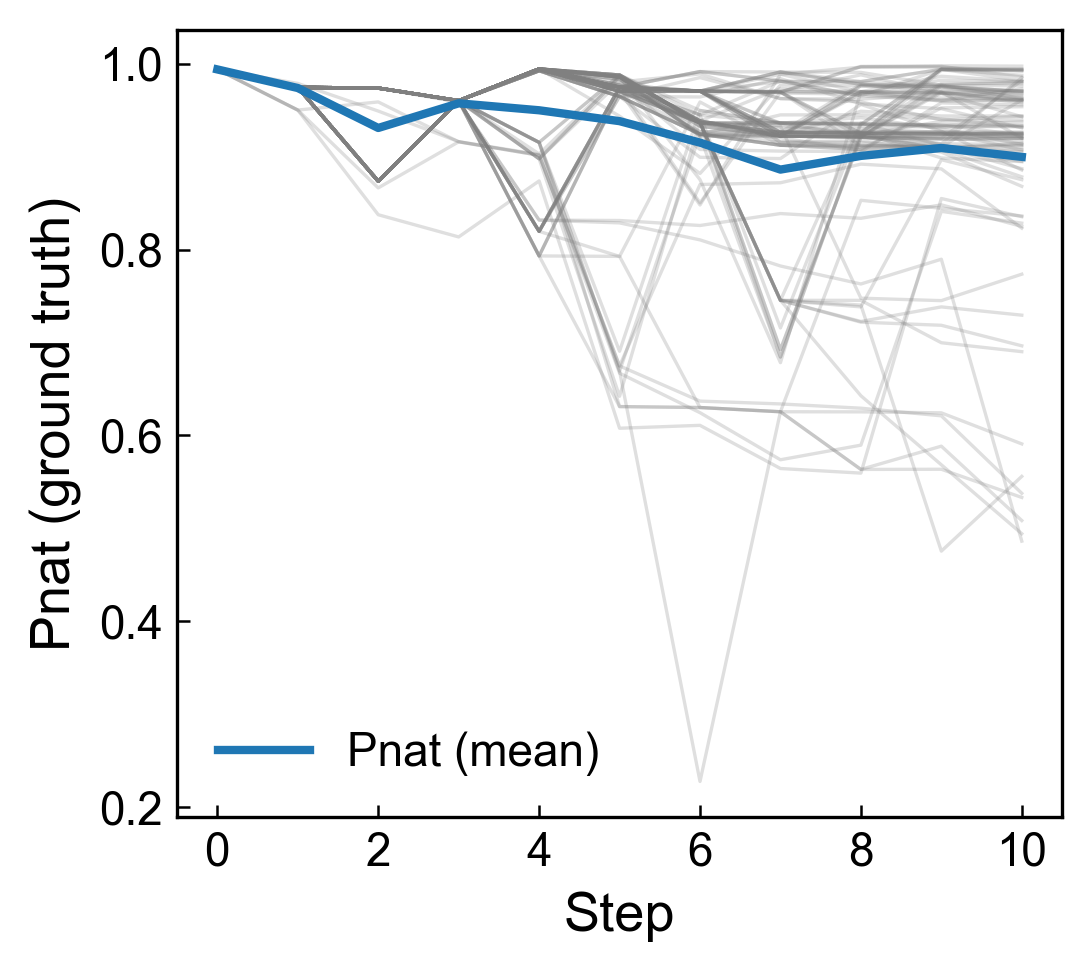

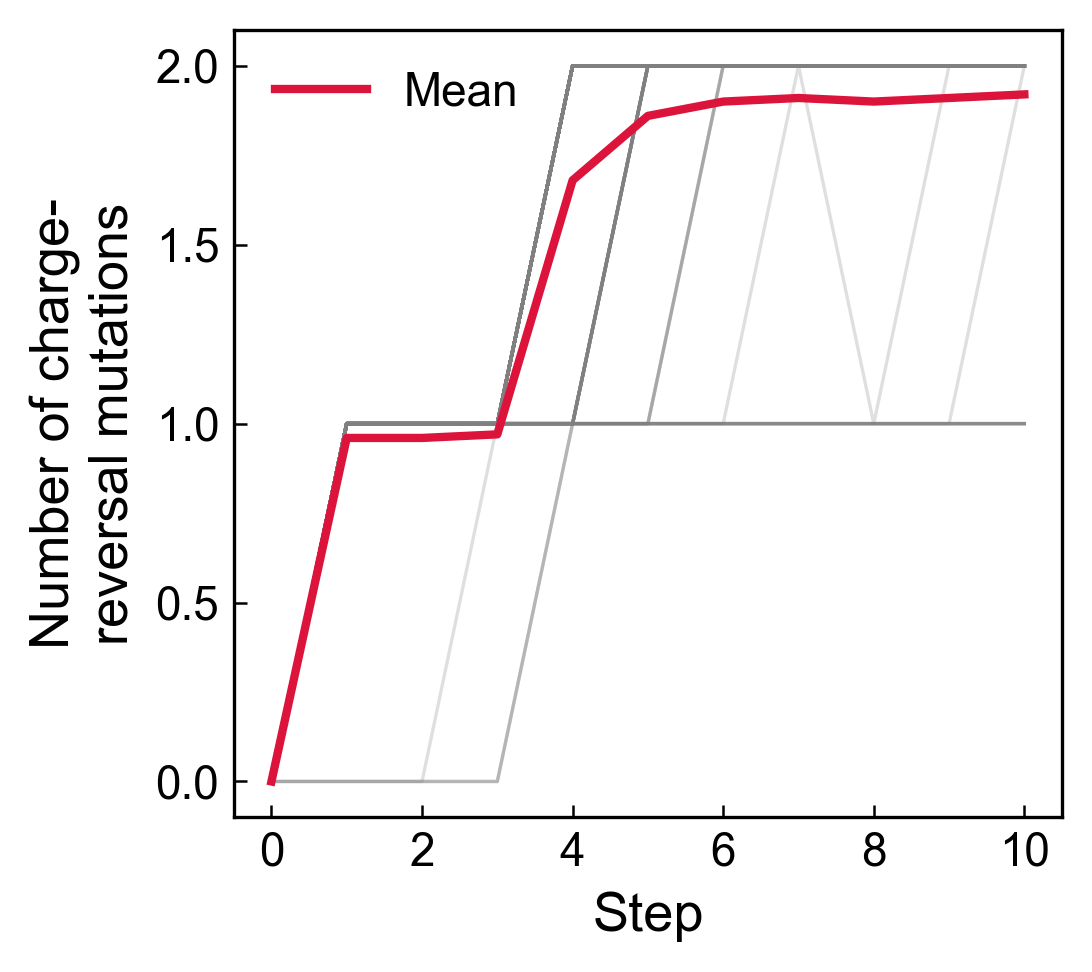

In [21]:
# -------------------
# Figure 1: Pnat (mean + faint individual paths)
# -------------------
fig, ax = plt.subplots(figsize=(3.8, 3.4))

for arr in all_ll_customed_rbm:
    ax.plot(steps, arr, color='gray', alpha=0.25, lw=0.8)

mean_customed = np.mean(np.vstack(all_ll_customed_rbm), axis=0)
ax.plot(steps, mean_customed, label="Pnat (mean)", lw=2, color='tab:blue')

ax.set_xlabel("Step")
ax.set_ylabel("Pnat (ground truth)")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

# Full black frame, inward ticks
for s in ax.spines.values():
    s.set_visible(True); s.set_color('black'); s.set_linewidth(0.8)
ax.tick_params(direction='in', length=3, width=0.6)

ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.show()

# -------------------
# Figure 2: Epitope Hamming distance (mean + faint individual paths)
# -------------------
fig, ax = plt.subplots(figsize=(3.8, 3.4))

for arr in all_ll_biased_rbm:
    ax.plot(steps, arr, color='gray', alpha=0.25, lw=0.8)

mean_biased = np.mean(np.vstack(all_ll_biased_rbm), axis=0)
ax.plot(steps, mean_biased, label="Mean", lw=2, color='crimson')

ax.set_xlabel("Step")
ax.set_ylabel("Number of charge-\nreversal mutations")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

for s in ax.spines.values():
    s.set_visible(True); s.set_color('black'); s.set_linewidth(0.8)
ax.tick_params(direction='in', length=3, width=0.6)

ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.show()


# Indep model paths

In [22]:

dir_in = f"paths/indep_w_upper_T10_beta_ab_{beta_w}/"

# Plot style (similar to consensus epitope plots)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'font.size': 12,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 300
})

# -------------------
# Collect paths
# -------------------
all_ll_customed = []  # will hold arrays per path: Pnat (as in your exp(...) transform)
all_ll_biased   = []  # epitope Hamming distance per path

for path_no in tqdm(range(paths_nb), desc=f"Reading β_w={beta_w}"):
    fasta_file = os.path.join(dir_in, f"output_{path_no}.fasta")
    if not os.path.exists(fasta_file):
        continue

    seqs = list(SeqIO.parse(fasta_file, "fasta"))
    if len(seqs) == 0:
        continue

    wt_seq = str(seqs[0].seq)
    ll_customed = []
    ll_biased   = []

    for record in seqs:
        seq = str(record.seq)
        # Epitope Hamming distance to WT
        # epitope_overlap = sum(seq[j] != wt_seq[j] for j in epitope_sites)
        seq_num=Proteins_utils.seq2num(seq)[0]
        seq_num_one_hot=one_hot_encode_concat(seq_num)
        epitope_overlap=np.dot(seq_num_one_hot, w)
        # Pnat (ground truth) via your custom model
        try:
            pnat = customed_lattice(Lattice_model=lattice_model, beta_lattice=beta_lattice)(seq)
        except Exception:
            continue

        # Your original transform:
        #   ll_c = (pnat - epitope_overlap * beta_w) / beta_lattice
        #   Pnat-like value = exp(ll_c)
        ll_c = pnat  / beta_lattice
        ll_customed.append(np.exp(ll_c))

        # Store epitope Hamming
        ll_biased.append(epitope_overlap)

    if len(ll_customed) == 0 or len(ll_biased) == 0:
        continue

    all_ll_customed.append(np.array(ll_customed))
    all_ll_biased.append(np.array(ll_biased))

# Early exit if nothing loaded
if len(all_ll_customed) == 0 or len(all_ll_biased) == 0:
    raise RuntimeError("No valid paths were loaded for β_w=3. Check input files.")

# Align by common minimum length across paths (if variable length)
min_T = min(arr.shape[0] for arr in all_ll_customed)
all_ll_customed = [arr[:min_T] for arr in all_ll_customed]
all_ll_biased   = [arr[:min_T] for arr in all_ll_biased]
steps = np.arange(min_T)



Reading β_w=10: 100%|██████████| 100/100 [03:08<00:00,  1.88s/it]


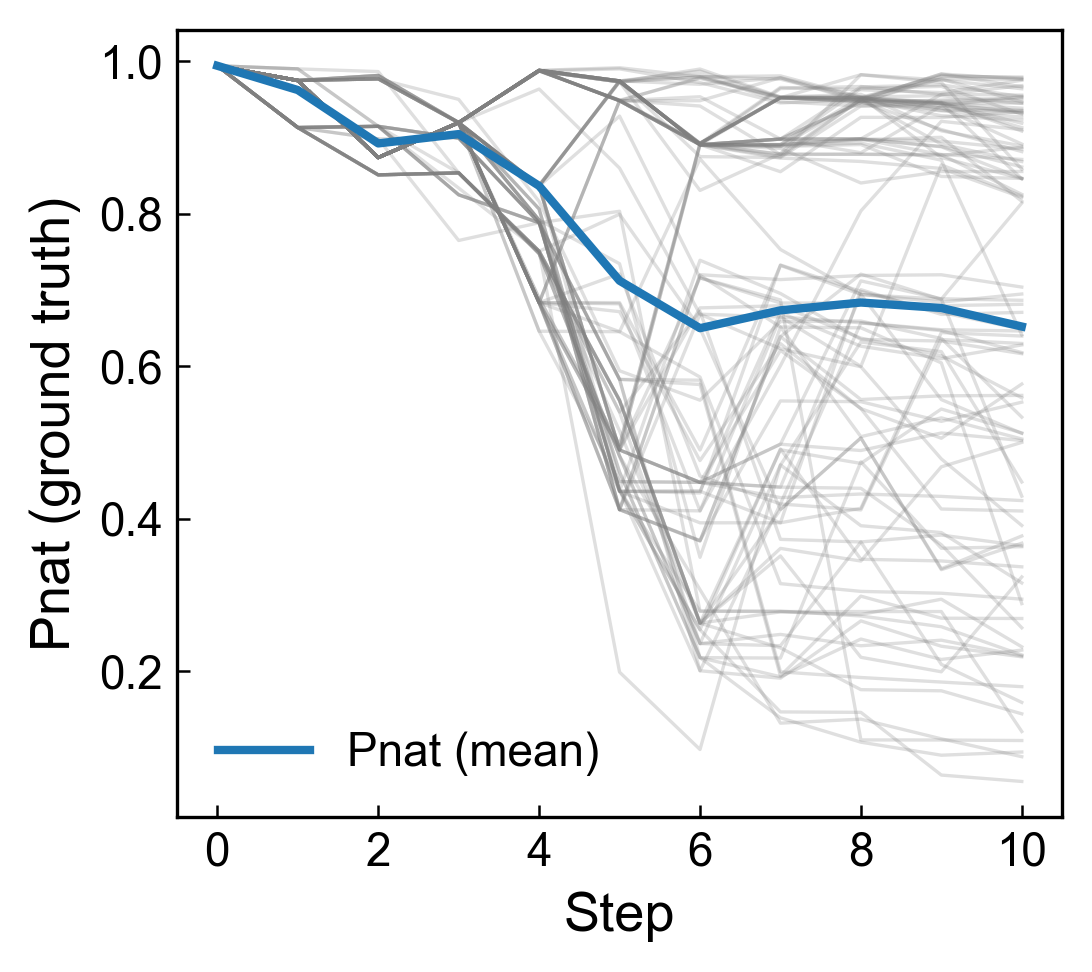

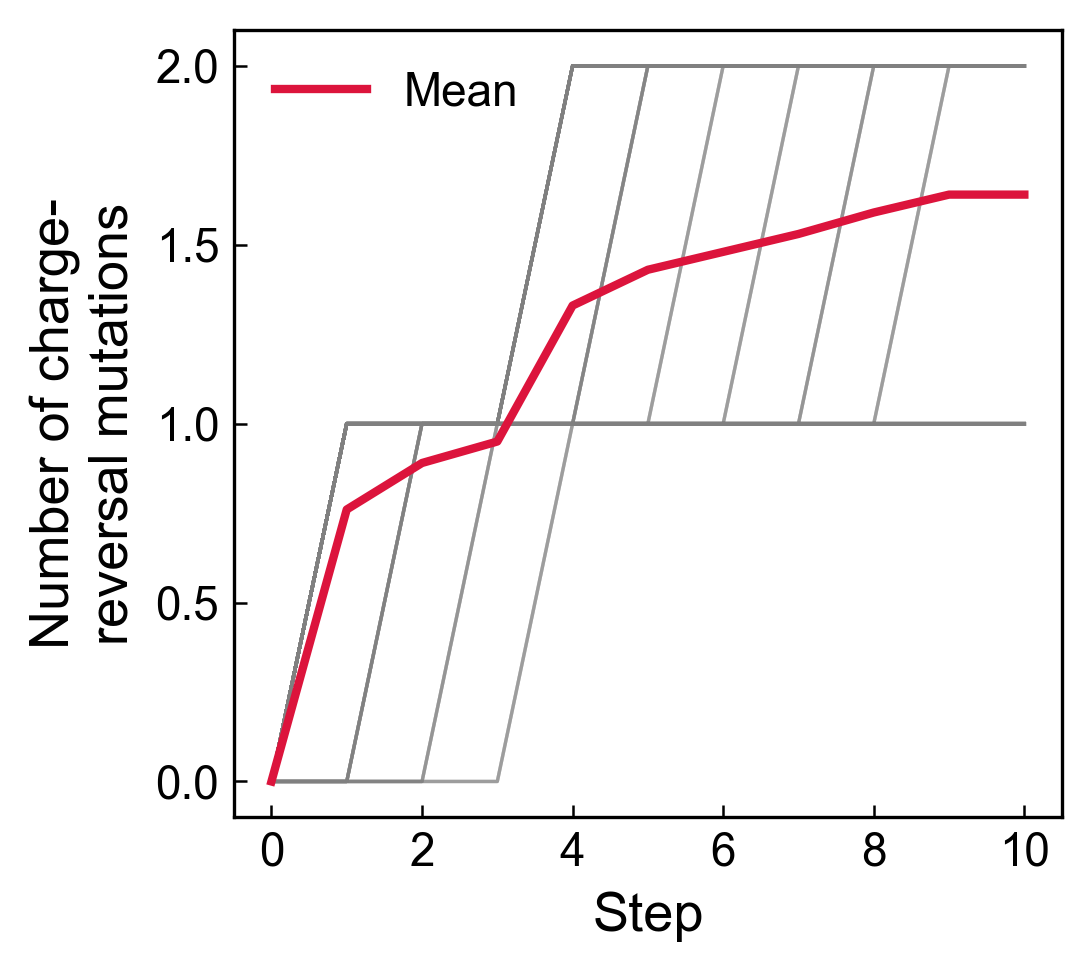

In [23]:
# -------------------
# Figure 1: Pnat (mean + faint individual paths)
# -------------------
fig, ax = plt.subplots(figsize=(3.8, 3.4))

for arr in all_ll_customed:
    ax.plot(steps, arr, color='gray', alpha=0.25, lw=0.8)

mean_customed = np.mean(np.vstack(all_ll_customed), axis=0)
ax.plot(steps, mean_customed, label="Pnat (mean)", lw=2, color='tab:blue')

ax.set_xlabel("Step")
ax.set_ylabel("Pnat (ground truth)")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

# Full black frame, inward ticks
for s in ax.spines.values():
    s.set_visible(True); s.set_color('black'); s.set_linewidth(0.8)
ax.tick_params(direction='in', length=3, width=0.6)

ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.show()

# -------------------
# Figure 2: Epitope Hamming distance (mean + faint individual paths)
# -------------------
fig, ax = plt.subplots(figsize=(3.8, 3.4))

for arr in all_ll_biased:
    ax.plot(steps, arr, color='gray', alpha=0.25, lw=0.8)

mean_biased = np.mean(np.vstack(all_ll_biased), axis=0)
ax.plot(steps, mean_biased, label="Mean", lw=2, color='crimson')

ax.set_xlabel("Step")
ax.set_ylabel("Number of charge-\nreversal mutations")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

for s in ax.spines.values():
    s.set_visible(True); s.set_color('black'); s.set_linewidth(0.8)
ax.tick_params(direction='in', length=3, width=0.6)

ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.show()


# percentage non viable paths

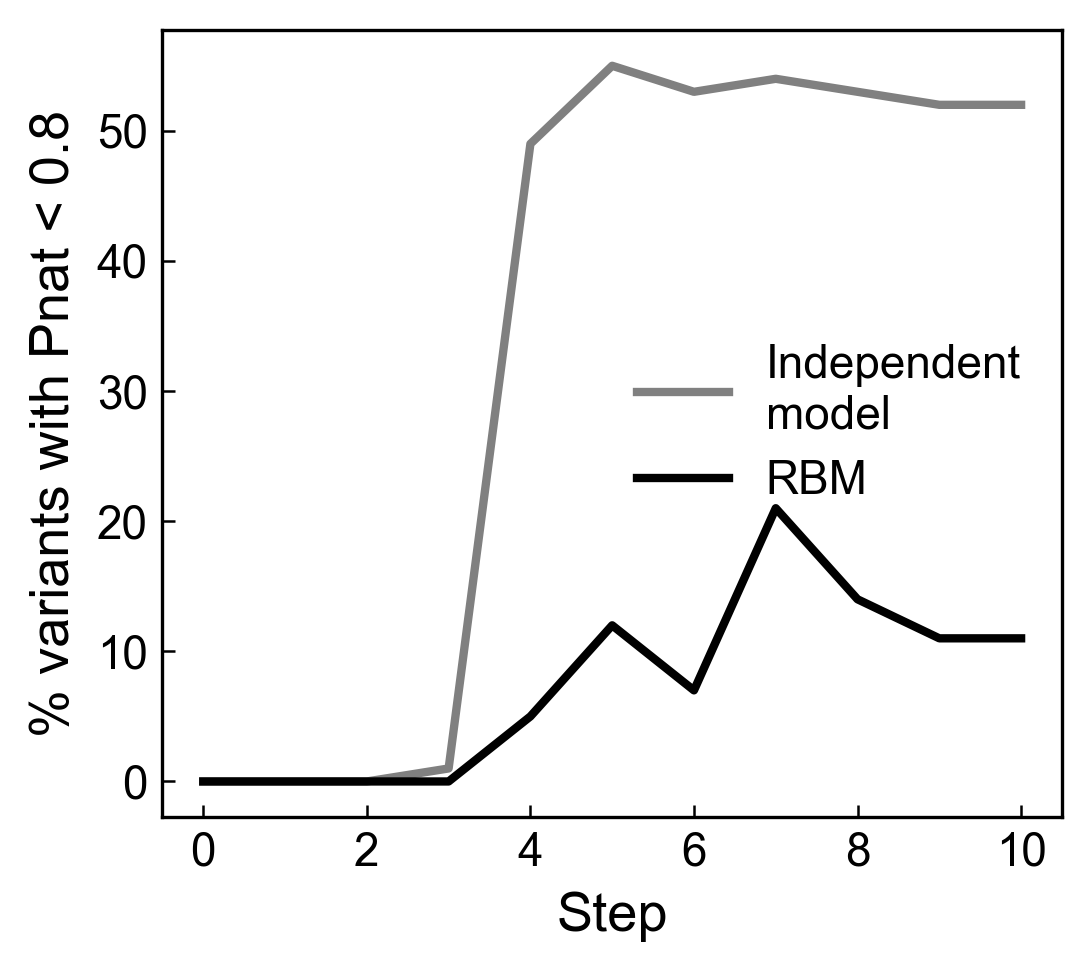

In [25]:

# -------------------
# 1. Calculations
# -------------------
TH = 0.8

# Helper function to compute percentage over time
def get_pct_below_threshold(data_list, threshold):
    # Stack to shape (N_paths, T_steps)
    mat = np.vstack(data_list)
    # Check condition < TH, sum over paths (axis 0), divide by N_paths
    # This results in an array of shape (T_steps,)
    return np.mean(mat < threshold, axis=0) * 100

# Compute for both models
pct_customed = get_pct_below_threshold(all_ll_customed, TH)
pct_rbm = get_pct_below_threshold(all_ll_customed_rbm, TH)

# -------------------
# 2. Plotting
# -------------------
fig, ax = plt.subplots(figsize=(3.8, 3.4))
steps = np.arange(len(pct_customed))
# Plot the percentage curves
ax.plot(steps, pct_customed, label="Independent\nmodel", lw=2, color='grey')
ax.plot(steps, pct_rbm, label="RBM", lw=2, color='black')

ax.set_xlabel("Step")
ax.set_ylabel(f"% variants with Pnat < {TH}")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

# Full black frame, inward ticks (Your specific style)
for s in ax.spines.values():
    s.set_visible(True); s.set_color('black'); s.set_linewidth(0.8)
ax.tick_params(direction='in', length=3, width=0.6)

ax.legend(frameon=False, loc='right')
plt.tight_layout()
plt.show()
